In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan

sys.path.append("/glade/u/home/islas/python/CESM2_with_CMIP7_aer/utils/")

from convert_units import *
from molecular_weights import *

from CASutils import calendar_utils as cal


In [4]:
louisas

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 3301, lat: 192, lon: 288)
Coordinates:
  * lat               (lat) float32 768B -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon               (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time              (time) datetime64[ns] 26kB 1750-01-16 ... 2100-12-10
Data variables:
    date              (time) int32 13kB ...
    emiss_ag_sol_was  (time, lat, lon) float32 730MB ...
    emiss_shipping    (time, lat, lon) float32 730MB ...
Attributes: (12/13)
    data_title:                Anthropogenic surface emissions of so4_a1 for ...
    molecular_weight:          115.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions from the Community Emission Data Sys...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170616
    ...                        ...
    history:                   Thu Sep 24 11:20:19 2020: ncrcat /gpfs/fs1/p/a...
    data_script:               /glade/u/home/emmons/CMIP6/emissions/make_emis...
    data_source_url:           http://www.globalchange.umd.edu/ceds/ceds-cmip...
    data_reference:            Hoesly et al., GMD, 2017 (http://www.geosci-mo...
    NCO:                       "4.6.2"
    nco_openmp_thread_number:  1

In [11]:
basepath="/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/emissions_ssp370/"

louisas = xr.open_dataset(basepath+
                       "emissions-cmip6-ScenarioMIP_IAMC-AIM-ssp370-1-1_so4_a1_anthro-ag-ship_surface_mol_175001-210101_0.9x1.25_c20200924.nc")
louisas_ag_sol_was = louisas.emiss_ag_sol_was
louisas_ship = louisas.emiss_shipping

basepath="/glade/campaign/cgd/cas/islas/python_savs/CESM2_with_CMIP7_aer/make_emissions/from_CEDS/CMIP6/"
my_ag = xr.open_dataset(basepath+
                        "so4_a1_ag_emissions_f09.nc").emiss

my_ship = xr.open_dataset(basepath+
                          "so4_a1_ship_emissions_f09.nc").emiss

my_slv_was = xr.open_dataset(basepath+
                             "so4_a1_slv_was_emissions_f09.nc").emiss

In [12]:
louisas_ag_sol_was_tg = convert_molecules_to_tg_specifywgt(louisas_ag_sol_was, mol_weights['so4_a1'])
louisas_ship_tg = convert_molecules_to_tg_specifywgt( louisas_ship, mol_weights['so4_a1'])
my_ag_tg = convert_molecules_to_tg_specifywgt(my_ag, mol_weights['so4_a1'])
my_ship_tg = convert_molecules_to_tg_specifywgt(my_ship, mol_weights['so4_a1'])
my_slv_was_tg = convert_molecules_to_tg_specifywgt(my_slv_was, mol_weights['so4_a1'])

In [13]:
louisas_ag_sol_was_tg_am = cal.calcannualmean(louisas_ag_sol_was_tg)
louisas_ship_tg_am = cal.calcannualmean(louisas_ship_tg)
my_ag_tg_am = cal.calcannualmean(my_ag_tg)
my_ship_tg_am = cal.calcannualmean(my_ship_tg)
my_slv_was_tg_am = cal.calcannualmean(my_slv_was_tg)

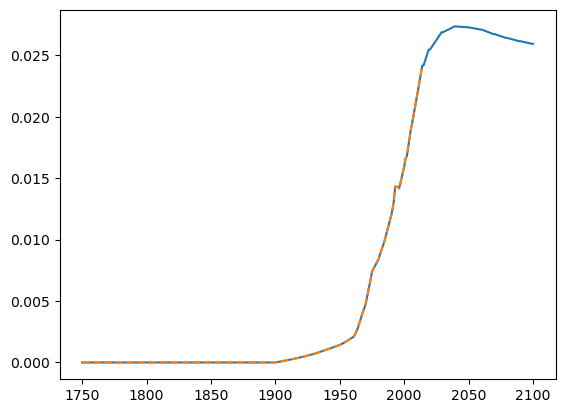

In [14]:
plt.plot(louisas_ag_sol_was_tg_am.year, louisas_ag_sol_was_tg_am)
plt.plot(my_ag_tg_am.year, my_ag_tg_am + my_slv_was_tg_am, linestyle='dashed')

In [10]:
plt.plot(louisas_ship_tg_am.year, louisas_ship_tg_am)
plt.plot(my_ag_tg_am.year, my_ag_tg_am + my_slv_was_tg_am, linestyle='dashed')

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 3301, lat: 192, lon: 288)
Coordinates:
  * lat               (lat) float32 768B -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon               (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time              (time) datetime64[ns] 26kB 1750-01-16 ... 2100-12-10
Data variables:
    date              (time) int32 13kB ...
    emiss_ag_sol_was  (time, lat, lon) float32 730MB ...
    emiss_shipping    (time, lat, lon) float32 730MB ...
Attributes: (12/13)
    data_title:                Anthropogenic surface emissions of so4_a1 for ...
    molecular_weight:          115.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions from the Community Emission Data Sys...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170616
    ...                        ...
    history:                   Thu Sep 24 11:20:19 2020: ncrcat /gpfs/fs1/p/a...
    data_script:               /glade/u/home/emmons/CMIP6/emissions/make_emis...
    data_source_url:           http://www.globalchange.umd.edu/ceds/ceds-cmip...
    data_reference:            Hoesly et al., GMD, 2017 (http://www.geosci-mo...
    NCO:                       "4.6.2"
    nco_openmp_thread_number:  1